# 🚀 TimeGAN - Forex Synthetic Data Generation

Bu notebook TimeGAN ile forex verisi üretmek için hazırlanmıştır.

**Manuel implementasyon - ydata-synthetic Python 3.12 desteklemiyor**

---
⚠️ **GPU'yu aktifleştir:** Runtime > Change runtime type > T4 GPU

## 1️⃣ Kütüphaneleri Kur

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn tensorflow -q
print('✅ Kurulum tamamlandı!')

✅ Kurulum tamamlandı!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2️⃣ Veriyi Yükle

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_no_weekend.csv to cleaned_no_weekend.csv


In [ ]:
df = pd.read_csv('cleaned_no_weekend.csv', index_col=0, parse_dates=True)
print(f'Veri boyutu: {df.shape}')
df.head()

Veri boyutu: (99904, 22)


,open,high,low,close,volume,spread,segment_id,logret,hl_range,body,...,sin_hour,cos_hour,sin_dow,cos_dow,atr,realized_vol,rsi,volume_ratio,future_return,direction
2009-10-16 00:00:00,1.49356,1.49402,1.49345,1.49391,704.0,0.0,0,NaN,0.000382,0.000234,...,0.000000,1.000000,-0.433884,-0.900969,0.000382,0.000000,0.000000,1.000000,-0.000502,0.0
2009-10-16 01:00:00,1.49390,1.49564,1.49314,1.49527,1421.0,0.0,0,0.000910,0.001672,0.000916,...,0.258819,0.965926,-0.433884,-0.900969,0.001027,0.000000,0.000000,1.337412,-0.002075,0.0
2009-10-16 02:00:00,1.49524,1.49644,1.49462,1.49641,2180.0,0.0,0,0.000762,0.001216,0.000782,...,0.500000,0.866025,-0.433884,-0.900969,0.001089,0.000105,0.000000,1.519164,-0.003106,0.0
2009-10-16 03:00:00,1.49642,1.49651,1.49479,1.49548,1523.0,0.0,0,-0.000622,0.001150,-0.000629,...,0.707107,0.707107,-0.433884,-0.900969,0.001105,0.000845,0.457726,1.045299,-0.003275,0.0
2009-10-16 04:00:00,1.49543,1.49637,1.49350,1.49395,1659.0,0.0,0,-0.001024,0.001921,-0.000991,...,0.866025,0.500000,-0.433884,-0.900969,0.001269,0.000973,0.008065,1.107920,-0.002473,0.0


In [ ]:
FEATURES = [
    'logret', 'hl_range', 'body', 'atr', 'realized_vol',
    'rsi', 'volume_ratio', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow'
]

data = df[FEATURES].dropna().values
print(f'Kullanılacak veri: {data.shape}')

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

Kullanılacak veri: (99903, 11)


In [ ]:
# Hyperparametreler
SEQ_LEN = 24       # Sequence uzunluğu
HIDDEN_DIM = 128   # Hidden layer boyutu
NUM_LAYERS = 3     # GRU layer sayısı
BATCH_SIZE = 128   # Batch size
EPOCHS = 500       # Epoch sayısı (ücretsiz için 300-500, Pro+ için 1000+)
NOISE_DIM = 32     # Noise dimension

N_FEATURES = len(FEATURES)

In [ ]:
def create_sequences(data, seq_len):
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i:i+seq_len])
    return np.array(sequences)

sequences = create_sequences(data_scaled, SEQ_LEN)
print(f'Sequences: {sequences.shape}')

Sequences: (99879, 24, 11)


## 3️⃣ TimeGAN Model Tanımları

In [ ]:
def make_embedder():
    """Veriyi latent space'e embed eder"""
    model = keras.Sequential([
        layers.InputLayer(input_shape=(SEQ_LEN, N_FEATURES)),
        layers.GRU(HIDDEN_DIM, return_sequences=True),
        layers.GRU(HIDDEN_DIM, return_sequences=True),
        layers.TimeDistributed(layers.Dense(HIDDEN_DIM, activation='sigmoid'))
    ], name='embedder')
    return model

def make_recovery():
    """Latent space'den veriyi geri çevirir"""
    model = keras.Sequential([
        layers.InputLayer(input_shape=(SEQ_LEN, HIDDEN_DIM)),
        layers.GRU(HIDDEN_DIM, return_sequences=True),
        layers.GRU(HIDDEN_DIM, return_sequences=True),
        layers.TimeDistributed(layers.Dense(N_FEATURES, activation='sigmoid'))
    ], name='recovery')
    return model

def make_generator():
    """Noise'dan sentetik embedding üretir"""
    model = keras.Sequential([
        layers.InputLayer(input_shape=(SEQ_LEN, NOISE_DIM)),
        layers.GRU(HIDDEN_DIM, return_sequences=True),
        layers.GRU(HIDDEN_DIM, return_sequences=True),
        layers.TimeDistributed(layers.Dense(HIDDEN_DIM, activation='sigmoid'))
    ], name='generator')
    return model

def make_supervisor():
    """Sequence'lerin temporal dinamiklerini öğrenir"""
    model = keras.Sequential([
        layers.InputLayer(input_shape=(SEQ_LEN, HIDDEN_DIM)),
        layers.GRU(HIDDEN_DIM, return_sequences=True),
        layers.TimeDistributed(layers.Dense(HIDDEN_DIM, activation='sigmoid'))
    ], name='supervisor')
    return model

def make_discriminator():
    """Gerçek vs sentetik ayırt eder"""
    model = keras.Sequential([
        layers.InputLayer(input_shape=(SEQ_LEN, HIDDEN_DIM)),
        layers.GRU(HIDDEN_DIM, return_sequences=True),
        layers.GRU(HIDDEN_DIM),
        layers.Dense(1)
    ], name='discriminator')
    return model

In [ ]:
# Modelleri oluştur
embedder = make_embedder()
recovery = make_recovery()
generator = make_generator()
supervisor = make_supervisor()
discriminator = make_discriminator()

# Optimizer'lar
autoencoder_opt = keras.optimizers.Adam(1e-3)
supervisor_opt = keras.optimizers.Adam(1e-3)
generator_opt = keras.optimizers.Adam(1e-4)
discriminator_opt = keras.optimizers.Adam(1e-4)

print('✅ Modeller oluşturuldu!')

✅ Modeller oluşturuldu!


## 4️⃣ Eğitim Fonksiyonları

In [ ]:
mse = keras.losses.MeanSquaredError()
bce = keras.losses.BinaryCrossentropy(from_logits=True)

@tf.function
def train_autoencoder_step(x):
    with tf.GradientTape() as tape:
        h = embedder(x, training=True)
        x_tilde = recovery(h, training=True)
        loss = mse(x, x_tilde)

    grads = tape.gradient(loss, embedder.trainable_variables + recovery.trainable_variables)
    autoencoder_opt.apply_gradients(zip(grads, embedder.trainable_variables + recovery.trainable_variables))
    return loss

@tf.function
def train_supervisor_step(x):
    with tf.GradientTape() as tape:
        h = embedder(x, training=False)
        h_hat = supervisor(h, training=True)
        loss = mse(h[:, 1:, :], h_hat[:, :-1, :])

    grads = tape.gradient(loss, supervisor.trainable_variables)
    supervisor_opt.apply_gradients(zip(grads, supervisor.trainable_variables))
    return loss

@tf.function
def train_generator_step(x, z):
    with tf.GradientTape() as tape:
        # Gerçek embedding
        h = embedder(x, training=False)

        # Sentetik embedding
        e_hat = generator(z, training=True)
        h_hat = supervisor(e_hat, training=False)

        # Discriminator'dan geçir
        y_fake = discriminator(h_hat, training=False)

        # Generator loss
        g_loss_u = bce(tf.ones_like(y_fake), y_fake)
        g_loss_s = mse(h[:, 1:, :], h_hat[:, :-1, :])

        # Moments için
        x_hat = recovery(h_hat, training=False)
        g_loss_v = tf.reduce_mean(tf.abs(tf.math.reduce_std(x_hat, axis=0) - tf.math.reduce_std(x, axis=0)))
        g_loss_v += tf.reduce_mean(tf.abs(tf.math.reduce_mean(x_hat, axis=0) - tf.math.reduce_mean(x, axis=0)))

        g_loss = g_loss_u + 100 * tf.sqrt(g_loss_s) + 100 * g_loss_v

    grads = tape.gradient(g_loss, generator.trainable_variables + supervisor.trainable_variables)
    generator_opt.apply_gradients(zip(grads, generator.trainable_variables + supervisor.trainable_variables))
    return g_loss

@tf.function
def train_discriminator_step(x, z):
    with tf.GradientTape() as tape:
        h = embedder(x, training=False)
        e_hat = generator(z, training=False)
        h_hat = supervisor(e_hat, training=False)

        y_real = discriminator(h, training=True)
        y_fake = discriminator(h_hat, training=True)

        d_loss_real = bce(tf.ones_like(y_real), y_real)
        d_loss_fake = bce(tf.zeros_like(y_fake), y_fake)
        d_loss = d_loss_real + d_loss_fake

    grads = tape.gradient(d_loss, discriminator.trainable_variables)
    discriminator_opt.apply_gradients(zip(grads, discriminator.trainable_variables))
    return d_loss

## 5️⃣ Eğitimi Başlat

In [ ]:
# Dataset oluştur
dataset = tf.data.Dataset.from_tensor_slices(sequences.astype('float32'))
dataset = dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f'Dataset hazır! Batch sayısı: {len(dataset)}')

Dataset hazır! Batch sayısı: 781


In [ ]:
# Phase 1: Autoencoder eğitimi
print('📍 Phase 1: Autoencoder Eğitimi')
for epoch in range(EPOCHS // 5):
    losses = []
    for batch in dataset:
        loss = train_autoencoder_step(batch)
        losses.append(loss.numpy())
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS//5} - Loss: {np.mean(losses):.6f}')

print('✅ Phase 1 tamamlandı!')

📍 Phase 1: Autoencoder Eğitimi
Epoch 20/100 - Loss: 0.000013
Epoch 40/100 - Loss: 0.000009
Epoch 60/100 - Loss: 0.000005
Epoch 80/100 - Loss: 0.000004
Epoch 100/100 - Loss: 0.000003
✅ Phase 1 tamamlandı!


In [ ]:
# Phase 2: Supervisor eğitimi
print('📍 Phase 2: Supervisor Eğitimi')
for epoch in range(EPOCHS // 5):
    losses = []
    for batch in dataset:
        loss = train_supervisor_step(batch)
        losses.append(loss.numpy())
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS//5} - Loss: {np.mean(losses):.6f}')

print('✅ Phase 2 tamamlandı!')

📍 Phase 2: Supervisor Eğitimi
Epoch 20/100 - Loss: 0.002478
Epoch 40/100 - Loss: 0.002224
Epoch 60/100 - Loss: 0.002017
Epoch 80/100 - Loss: 0.001895
Epoch 100/100 - Loss: 0.001803
✅ Phase 2 tamamlandı!


In [15]:
# Phase 3: Joint eğitim (Generator + Discriminator)
print('📍 Phase 3: Joint Eğitim (GAN)')
for epoch in range(EPOCHS):
    g_losses, d_losses = [], []

    for batch in dataset:
        # Random noise
        z = tf.random.uniform((batch.shape[0], SEQ_LEN, NOISE_DIM), 0, 1)

        # Generator 2x, Discriminator 1x
        g_loss = train_generator_step(batch, z)
        g_loss = train_generator_step(batch, z)
        d_loss = train_discriminator_step(batch, z)

        g_losses.append(g_loss.numpy())
        d_losses.append(d_loss.numpy())

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} - G_Loss: {np.mean(g_losses):.4f}, D_Loss: {np.mean(d_losses):.4f}')

print('✅ Phase 3 tamamlandı!')

📍 Phase 3: Joint Eğitim (GAN)
Epoch 50/500 - G_Loss: 33.5519, D_Loss: 0.3436
Epoch 100/500 - G_Loss: 34.6266, D_Loss: 0.2635
Epoch 150/500 - G_Loss: 34.7061, D_Loss: 0.3433
Epoch 200/500 - G_Loss: 35.6179, D_Loss: 0.2440
Epoch 250/500 - G_Loss: 36.0463, D_Loss: 0.1831
Epoch 300/500 - G_Loss: 35.9957, D_Loss: 0.2083
Epoch 350/500 - G_Loss: 37.9561, D_Loss: 0.1836
Epoch 400/500 - G_Loss: 36.1539, D_Loss: 0.2227
Epoch 450/500 - G_Loss: 36.3253, D_Loss: 0.1953
Epoch 500/500 - G_Loss: 36.0034, D_Loss: 0.2090
✅ Phase 3 tamamlandı!


In [16]:
# Modelleri kaydet
embedder.save('timegan_embedder.keras')
recovery.save('timegan_recovery.keras')
generator.save('timegan_generator.keras')
supervisor.save('timegan_supervisor.keras')

print('✅ Modeller kaydedildi!')

✅ Modeller kaydedildi!


## 6️⃣ Sentetik Veri Üret

In [17]:
def generate_synthetic_data(n_samples):
    """Sentetik veri üret"""
    z = tf.random.uniform((n_samples, SEQ_LEN, NOISE_DIM), 0, 1)
    e_hat = generator(z, training=False)
    h_hat = supervisor(e_hat, training=False)
    x_hat = recovery(h_hat, training=False)
    return x_hat.numpy()

# 1000 sequence üret
n_samples = 1000
synthetic_sequences = generate_synthetic_data(n_samples)
print(f'Sentetik veri: {synthetic_sequences.shape}')

Sentetik veri: (1000, 24, 11)


In [18]:
# Inverse transform
synthetic_flat = synthetic_sequences.reshape(-1, N_FEATURES)
synthetic_original = scaler.inverse_transform(synthetic_flat)

df_synthetic = pd.DataFrame(synthetic_original, columns=FEATURES)
df_synthetic.head()

,logret,hl_range,body,atr,realized_vol,rsi,volume_ratio,sin_hour,cos_hour,sin_dow,cos_dow
0,-0.000128,0.000727,0.000005,0.002036,0.000872,-0.285396,1.450945,-0.992958,0.016416,-0.432847,-0.899627
1,-0.002313,0.002663,-0.002363,0.001874,0.001356,-0.483411,2.189940,-0.955891,0.307340,-0.433107,-0.900131
2,-0.001283,0.001881,-0.001322,0.001808,0.001111,-0.798187,1.220072,-0.887951,0.451458,-0.432962,-0.900120
3,-0.000100,0.001383,-0.000249,0.002050,0.001487,-0.419460,1.024421,-0.738056,0.684725,-0.433223,-0.900218
4,-0.000220,0.001219,-0.000157,0.001955,0.001371,-0.278117,1.084913,-0.487782,0.875293,-0.433113,-0.900344


## 7️⃣ Karşılaştırma

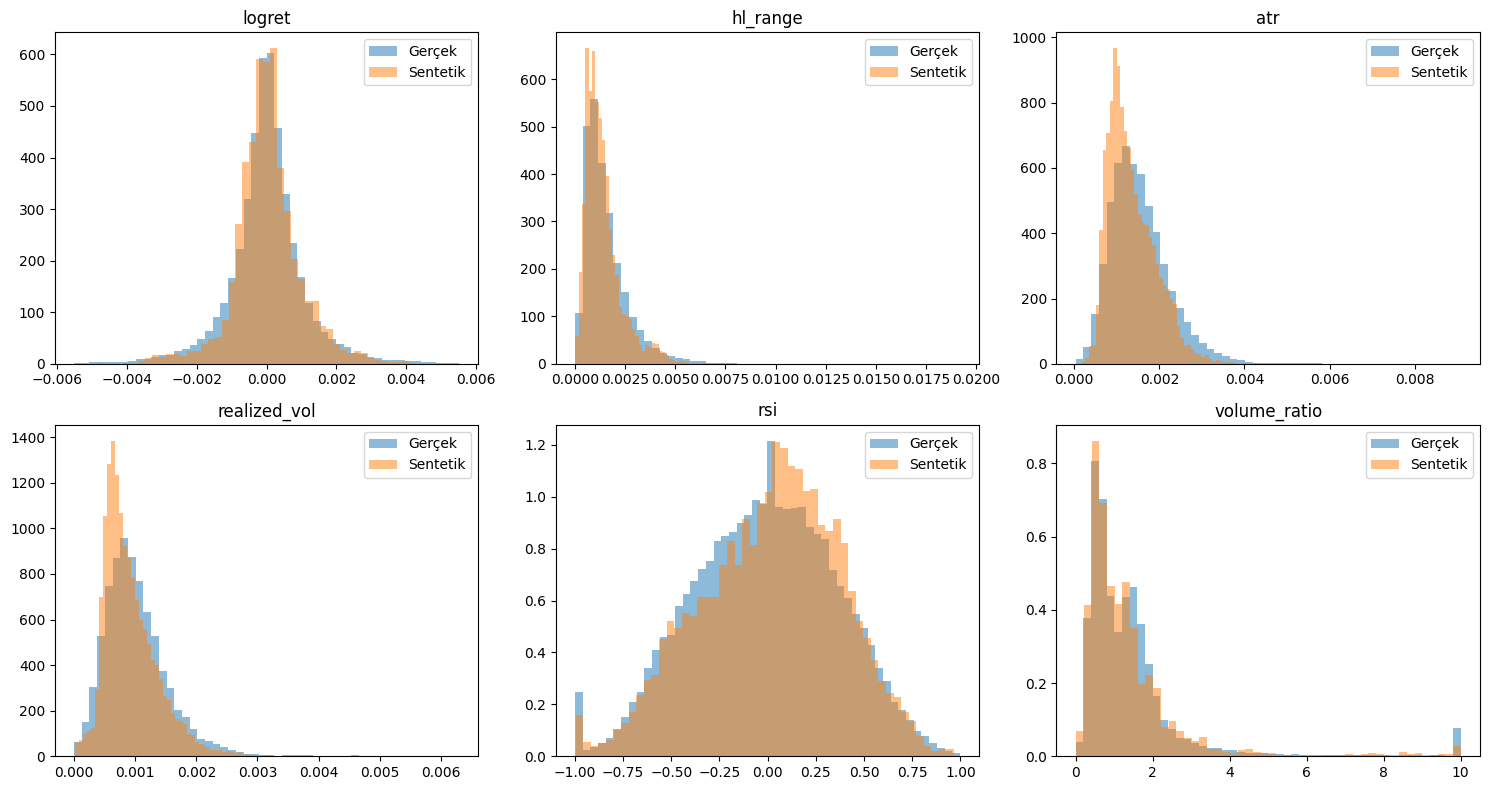

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features_to_plot = ['logret', 'hl_range', 'atr', 'realized_vol', 'rsi', 'volume_ratio']

for i, feat in enumerate(features_to_plot):
    ax = axes[i//3, i%3]
    ax.hist(df[feat].dropna().values[:50000], bins=50, alpha=0.5, label='Gerçek', density=True)
    ax.hist(df_synthetic[feat].values, bins=50, alpha=0.5, label='Sentetik', density=True)
    ax.set_title(feat)
    ax.legend()

plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()

files.download('comparison.png')

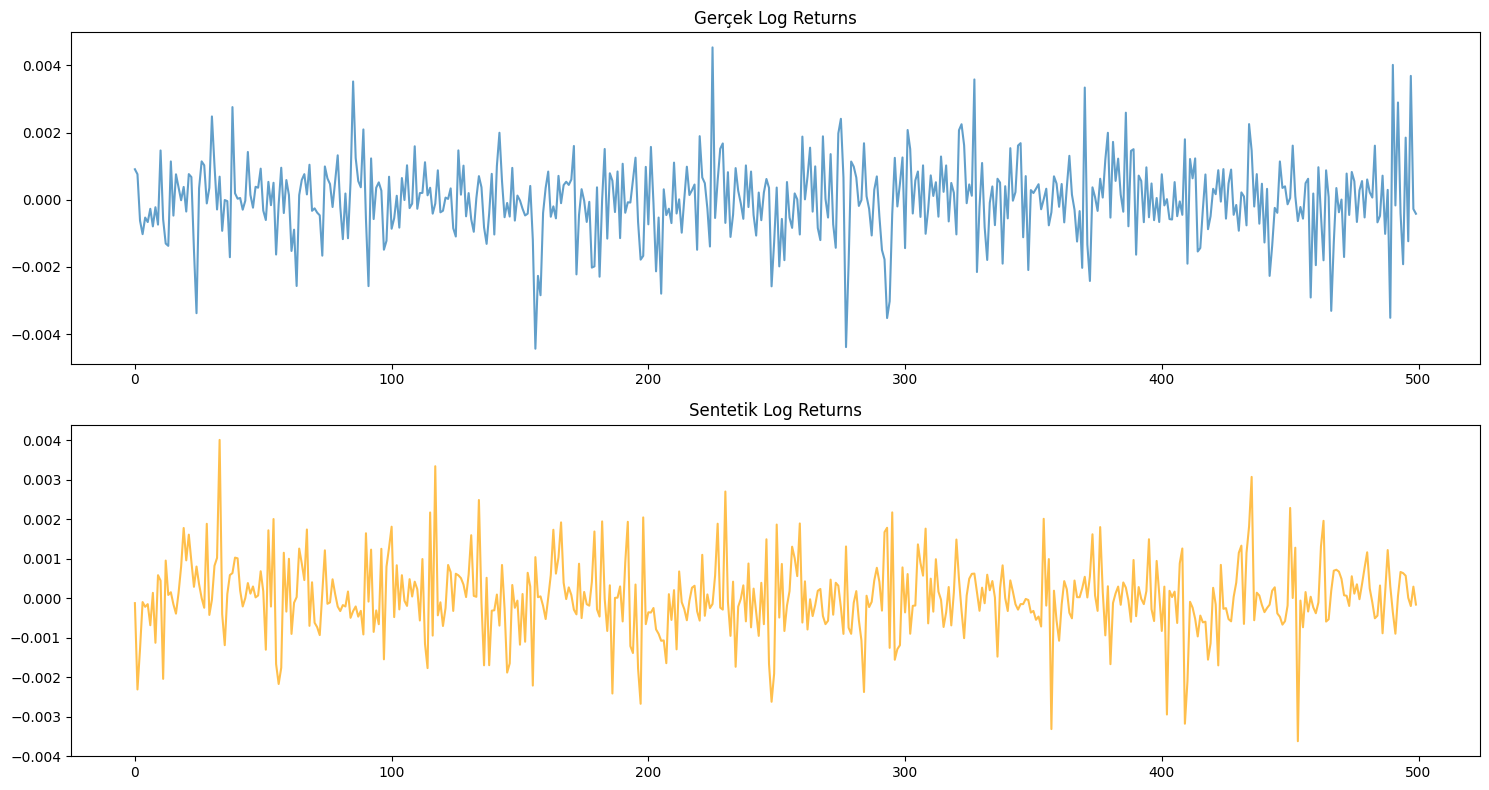

In [20]:
# Zaman serisi karşılaştırma
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].plot(df['logret'].dropna().values[:500], alpha=0.7)
axes[0].set_title('Gerçek Log Returns')

axes[1].plot(df_synthetic['logret'].values[:500], alpha=0.7, color='orange')
axes[1].set_title('Sentetik Log Returns')

plt.tight_layout()
plt.savefig('timeseries_comparison.png', dpi=150)
plt.show()

In [21]:
# Kaydet
df_synthetic.to_csv('synthetic_forex_timegan.csv', index=False)
files.download('synthetic_forex_timegan.csv')
print('✅ Sentetik veri indirildi!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Sentetik veri indirildi!


---
## 🎉 Tebrikler!

**Pro+ önerileri:**
- `EPOCHS = 1000+`
- `SEQ_LEN = 48` (2 gün)
- `HIDDEN_DIM = 256`